# 12d · Transfer Learning — Doom vs Animal Crossing

## What changed from 11d EDA → 12d model

| EDA Finding | Design Decision |
|---|---|
| Doom **brighter** (140.7) than AC (110.3) — distributions heavily overlap, saturation identical | Colour alone is weak → need deep visual features from pretrained model |
| Images are complex (memes with text, screenshots, real photos, comic panels) | Scratch CNN on 1385 images will underfit — use **EfficientNetB0 pretrained on ImageNet** |
| High resolution (mean 1346×1246) — resizing to 128px loses detail | Use **224×224** (EfficientNet native size) instead of 128 |
| Near-perfect class balance (51/49) | No class weighting needed |
| No domain shift train↔test | Standard stratified split is reliable |

**Core strategy:** EfficientNetB0 (ImageNet weights) → freeze backbone → train head → fine-tune full network. 5-fold stratified CV for OOF balanced accuracy. TTA at inference.


## 0 · Install & Imports

In [1]:
%pip install -q tensorflow scikit-learn pandas pillow tqdm matplotlib



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TF:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))


TF: 2.21.0
GPUs: []


## 1 · Config

In [3]:
BASE_DIR = '.'
IMG_DIR  = os.path.join(BASE_DIR, 'img')

# ── Image ─────────────────────────────────────────────────────
IMG_SIZE     = 224      # EfficientNetB0 native resolution
IMG_CHANNELS = 3

# ── Training ──────────────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS_HEAD  = 10       # train classifier head only (backbone frozen)
EPOCHS_FINE  = 20       # fine-tune full network at low LR
LR_HEAD      = 1e-3
LR_FINE      = 1e-5     # much lower for fine-tuning

# ── CV ────────────────────────────────────────────────────────
N_FOLDS      = 5
TTA_STEPS    = 5        # test-time augmentation passes

LABEL_MAP = {0: 'Animal Crossing', 1: 'Doom'}


## 2 · Load Labels

In [4]:
train_df = pd.read_csv(os.path.join(BASE_DIR, 'train-label.csv'))
test_df  = pd.read_csv(os.path.join(BASE_DIR, 'test-label.csv'))

print('Train:', train_df.shape, '| Test:', test_df.shape)
print(train_df['label'].value_counts().sort_index())
train_df.head()


Train: (1385, 3) | Test: (1386, 3)
label
0    707
1    678
Name: count, dtype: int64


,id,file,label
0,0,001bd5563b4511f0b16c00155d672fff.png,1
1,1,d13cde743b4411f0b16c00155d672fff.jpg,0
2,2,96f4bf1a3b4511f0b16c00155d672fff.jpg,1
3,3,43f18faa3b4511f0b16c00155d672fff.jpg,0
4,4,bf0df3a03b4411f0b16c00155d672fff.png,1


## 3 · Load & Preprocess Images

EfficientNetB0 expects pixel values in **[0, 255]** — we use `preprocess_input` internally in the model so we keep uint8 here and normalise inside the tf.data pipeline.

In [5]:
def load_image_array(filepath, size=IMG_SIZE):
    """Load image → RGB → resize → float32 [0,255]."""
    img = Image.open(filepath).convert('RGB')
    img = img.resize((size, size), Image.BILINEAR)
    return np.array(img, dtype=np.float32)

def load_all(df, img_dir, has_labels=True):
    X, y = [], []
    missing = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Loading'):
        path = os.path.join(img_dir, row['file'])
        if not os.path.exists(path):
            missing += 1
            continue
        X.append(load_image_array(path))
        if has_labels:
            y.append(int(row['label']))
    if missing:
        print(f'  ⚠️  {missing} images not found')
    X = np.stack(X).astype(np.float32)
    y = np.array(y, dtype=np.int32) if has_labels else None
    return X, y

print('Loading train ...')
X_all, y_all = load_all(train_df, IMG_DIR, has_labels=True)
print(f'  X_all: {X_all.shape}  y_all: {y_all.shape}')

print('Loading test ...')
X_test, _ = load_all(test_df, IMG_DIR, has_labels=False)
print(f'  X_test: {X_test.shape}')


Loading train ...


Loading: 100%|██████████| 1385/1385 [00:25<00:00, 53.36it/s]


  X_all: (1385, 224, 224, 3)  y_all: (1385,)
Loading test ...


Loading: 100%|██████████| 1386/1386 [00:27<00:00, 51.11it/s]


  X_test: (1386, 224, 224, 3)


## 4 · Model: EfficientNetB0 + Classifier Head

**Why EfficientNetB0?**
- Pretrained on 1.2M ImageNet images → rich general visual features (edges, textures, shapes)
- Compact & fast — good for 1385 training images
- Native 224×224 resolution preserves more detail than 128px scratch CNN

**Two-phase training:**
1. **Head-only phase** — freeze backbone, train only the dense classifier (fast, prevents destroying pretrained weights early)
2. **Fine-tune phase** — unfreeze full network at very low LR (lets backbone adapt to meme domain)


In [6]:
def build_efficientnet(input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS),
                       trainable_backbone=False):
    """EfficientNetB0 backbone + custom classification head."""    
    # Input normalisation: EfficientNetB0 expects [0,255] and handles
    # its own internal rescaling via preprocess_input
    inputs = keras.Input(shape=input_shape)
    
    # Backbone
    backbone = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs,
        pooling='avg'          # GlobalAveragePooling built in
    )
    backbone.trainable = trainable_backbone
    
    x = backbone.output
    
    # Classifier head
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(2, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='EfficientNetB0_Classifier')
    return model, backbone

# Preview
model_preview, _ = build_efficientnet()
print(f'Total params:     {model_preview.count_params():,}')
trainable = sum(tf.size(w).numpy() for w in model_preview.trainable_weights)
print(f'Trainable params: {trainable:,}  (head-only phase)')
del model_preview


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total params:     4,384,165
Trainable params: 331,522  (head-only phase)


## 5 · Augmentation Pipeline

Stronger augmentation than 1d — memes come from the wild so we want the model robust to crops, flips, colour shifts, and rotations.

In [7]:
def make_train_ds(X, y, batch_size=BATCH_SIZE, seed=SEED):
    AUTOTUNE = tf.data.AUTOTUNE
    
    @tf.function
    def augment(image, label):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
        image = tf.image.random_brightness(image, max_delta=0.2)
        image = tf.image.random_contrast(image, 0.7, 1.3)
        image = tf.image.random_saturation(image, 0.7, 1.3)
        image = tf.image.random_hue(image, 0.05)
        # Random crop: pad 10% then crop back
        pad = int(IMG_SIZE * 0.1)
        image = tf.image.pad_to_bounding_box(
            image, pad, pad, IMG_SIZE + 2*pad, IMG_SIZE + 2*pad)
        image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, IMG_CHANNELS])
        image = tf.clip_by_value(image, 0.0, 255.0)
        return image, label
    
    ds = (tf.data.Dataset
          .from_tensor_slices((X, y))
          .shuffle(len(X), seed=seed)
          .map(augment, num_parallel_calls=AUTOTUNE)
          .batch(batch_size)
          .prefetch(AUTOTUNE))
    return ds

def make_eval_ds(X, y=None, batch_size=BATCH_SIZE):
    AUTOTUNE = tf.data.AUTOTUNE
    if y is not None:
        ds = tf.data.Dataset.from_tensor_slices((X, y))
    else:
        ds = tf.data.Dataset.from_tensor_slices(X)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

print('Augmentation fns ready.')


Augmentation fns ready.


## 6 · 5-Fold Stratified CV + Two-Phase Training

Each fold:
1. Build fresh EfficientNetB0 (backbone frozen)
2. Train head for `EPOCHS_HEAD` epochs at `LR_HEAD`
3. Unfreeze backbone, train at `LR_FINE` for `EPOCHS_FINE` epochs
4. Predict OOF and test set

Final test predictions = **average of softmax probabilities across all 5 folds**.


In [8]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_probs  = np.zeros((len(X_all), 2), dtype=np.float32)
test_probs = np.zeros((len(X_test), 2), dtype=np.float32)
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_all, y_all)):
    print(f'\n{"="*55}')
    print(f'  FOLD {fold+1}/{N_FOLDS}')
    print(f'{"="*55}')
    
    X_tr, X_val = X_all[tr_idx], X_all[val_idx]
    y_tr, y_val = y_all[tr_idx], y_all[val_idx]
    
    train_ds = make_train_ds(X_tr, y_tr)
    val_ds   = make_eval_ds(X_val, y_val)
    test_ds  = make_eval_ds(X_test)
    
    # ── Phase 1: Head only ────────────────────────────────────
    model, backbone = build_efficientnet(trainable_backbone=False)
    model.compile(
        optimizer=keras.optimizers.Adam(LR_HEAD),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f'  Phase 1: training head ({EPOCHS_HEAD} epochs) ...')
    model.fit(
        train_ds, epochs=EPOCHS_HEAD, validation_data=val_ds,
        verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=5,
            restore_best_weights=True, verbose=0)]
    )
    val_acc_p1 = model.evaluate(val_ds, verbose=0)[1]
    print(f'  Phase 1 val acc: {val_acc_p1:.4f}')
    
    # ── Phase 2: Fine-tune full network ───────────────────────
    backbone.trainable = True
    model.compile(
        optimizer=keras.optimizers.Adam(LR_FINE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f'  Phase 2: fine-tuning full network ({EPOCHS_FINE} epochs) ...')
    model.fit(
        train_ds, epochs=EPOCHS_FINE, validation_data=val_ds,
        verbose=0,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=8,
                restore_best_weights=True, verbose=0),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=4,
                min_lr=1e-7, verbose=0)
        ]
    )
    
    # ── OOF predictions ───────────────────────────────────────
    oof_probs[val_idx] = model.predict(val_ds, verbose=0)
    oof_preds = np.argmax(oof_probs[val_idx], axis=1)
    fold_bal_acc = balanced_accuracy_score(y_val, oof_preds)
    fold_scores.append(fold_bal_acc)
    print(f'  Fold {fold+1} OOF Balanced Accuracy: {fold_bal_acc:.4f}')
    
    # ── TTA test predictions ──────────────────────────────────
    fold_test_probs = np.zeros((len(X_test), 2), dtype=np.float32)
    # Pass 0: no augmentation
    fold_test_probs += model.predict(test_ds, verbose=0)
    # Passes 1..TTA_STEPS: with augmentation
    tta_ds_list = [make_train_ds(X_test, np.zeros(len(X_test), dtype=np.int32),
                                  seed=SEED+i)
                   for i in range(TTA_STEPS)]
    for tta_ds in tta_ds_list:
        tta_probs = []
        for batch in tta_ds:
            imgs = batch[0]
            tta_probs.append(model.predict_on_batch(imgs))
        fold_test_probs += np.concatenate(tta_probs, axis=0)
    fold_test_probs /= (TTA_STEPS + 1)
    
    test_probs += fold_test_probs / N_FOLDS
    
    keras.backend.clear_session()

print(f'\n{"="*55}')
print(f'  CV Results')
print(f'{"="*55}')
for i, s in enumerate(fold_scores):
    print(f'  Fold {i+1}: {s:.4f}')
print(f'  Mean OOF Balanced Accuracy: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')



  FOLD 1/5
  Phase 1: training head (10 epochs) ...
  Phase 1 val acc: 0.9206
  Phase 2: fine-tuning full network (20 epochs) ...
  Fold 1 OOF Balanced Accuracy: 0.9098

  FOLD 2/5
  Phase 1: training head (10 epochs) ...
  Phase 1 val acc: 0.8556
  Phase 2: fine-tuning full network (20 epochs) ...
  Fold 2 OOF Balanced Accuracy: 0.8554

  FOLD 3/5
  Phase 1: training head (10 epochs) ...
  Phase 1 val acc: 0.8303
  Phase 2: fine-tuning full network (20 epochs) ...
  Fold 3 OOF Balanced Accuracy: 0.8664

  FOLD 4/5
  Phase 1: training head (10 epochs) ...
  Phase 1 val acc: 0.8556
  Phase 2: fine-tuning full network (20 epochs) ...
  Fold 4 OOF Balanced Accuracy: 0.8488

  FOLD 5/5
  Phase 1: training head (10 epochs) ...
  Phase 1 val acc: 0.8917
  Phase 2: fine-tuning full network (20 epochs) ...
  Fold 5 OOF Balanced Accuracy: 0.8726

  CV Results
  Fold 1: 0.9098
  Fold 2: 0.8554
  Fold 3: 0.8664
  Fold 4: 0.8488
  Fold 5: 0.8726
  Mean OOF Balanced Accuracy: 0.8706 ± 0.0213


## 7 · OOF Summary & Training Curves

Overall OOF Balanced Accuracy: 0.8706
  Animal Crossing   : 0.8769
  Doom              : 0.8643


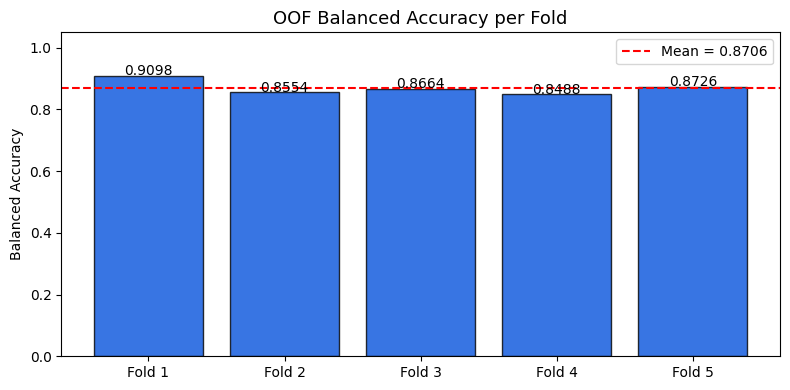

In [9]:
# Overall OOF balanced accuracy
oof_preds_all = np.argmax(oof_probs, axis=1)
overall_bal_acc = balanced_accuracy_score(y_all, oof_preds_all)
print(f'Overall OOF Balanced Accuracy: {overall_bal_acc:.4f}')

# Per-class accuracy
for cls, name in [(0, 'Animal Crossing'), (1, 'Doom')]:
    mask = y_all == cls
    cls_acc = (oof_preds_all[mask] == y_all[mask]).mean()
    print(f'  {name:18s}: {cls_acc:.4f}')

# Fold scores bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'Fold {i+1}' for i in range(N_FOLDS)], fold_scores,
              color='#0652DD', edgecolor='black', alpha=0.8)
ax.axhline(np.mean(fold_scores), color='red', linestyle='--',
           label=f'Mean = {np.mean(fold_scores):.4f}')
for bar, s in zip(bars, fold_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{s:.4f}', ha='center', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Balanced Accuracy')
ax.set_title('OOF Balanced Accuracy per Fold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


## 8 · Final Test Predictions

Test prediction distribution:
  0 (Animal Crossing): 774 (55.8%)
  1 (Doom): 612 (44.2%)

Mean confidence: 0.628
Low-confidence (<0.6) predictions: 650


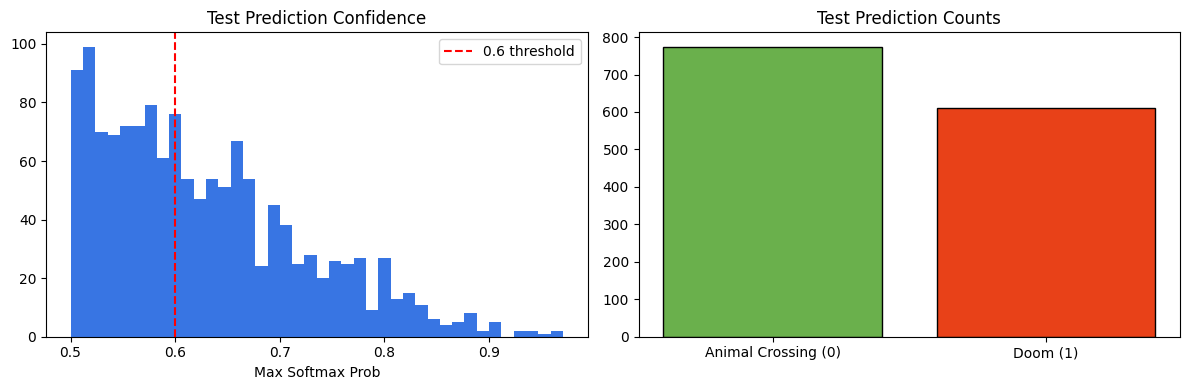

In [10]:
test_preds = np.argmax(test_probs, axis=1)

print('Test prediction distribution:')
for cls, name in [(0, 'Animal Crossing'), (1, 'Doom')]:
    count = (test_preds == cls).sum()
    print(f'  {cls} ({name}): {count} ({count/len(test_preds)*100:.1f}%)')

# Confidence distribution
confidence = test_probs.max(axis=1)
print(f'\nMean confidence: {confidence.mean():.3f}')
print(f'Low-confidence (<0.6) predictions: {(confidence < 0.6).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(confidence, bins=40, color='#0652DD', edgecolor='none', alpha=0.8)
axes[0].axvline(0.6, color='red', linestyle='--', label='0.6 threshold')
axes[0].set_title('Test Prediction Confidence'); axes[0].set_xlabel('Max Softmax Prob')
axes[0].legend()

axes[1].bar(['Animal Crossing (0)', 'Doom (1)'],
            [(test_preds==0).sum(), (test_preds==1).sum()],
            color=['#6ab04c','#e84118'], edgecolor='black')
axes[1].set_title('Test Prediction Counts')
plt.tight_layout()
plt.show()


## 9 · Save Submission

In [11]:
submission = pd.DataFrame({
    'id':    test_df['id'].values,
    'label': test_preds
})
submission.to_csv('submission12.csv', index=False)
print(submission.head(10))
print(f'\nSaved submission12.csv — {len(submission)} rows')

# Verify
assert len(submission) == len(test_df), 'Row count mismatch!'
assert set(submission['label'].unique()).issubset({0,1}), 'Bad labels!'
print('✅ submission12.csv looks correct')


     id  label
0  2078      1
1  2079      0
2  2080      0
3  2081      0
4  2082      1
5  2083      1
6  2084      0
7  2085      1
8  2086      0
9  2087      0

Saved submission12.csv — 1386 rows
✅ submission12.csv looks correct


## 10 · What We Did & Why It Should Work Better

| Improvement | 1d (baseline) | 12d (this notebook) |
|---|---|---|
| Backbone | Scratch CNN (4 blocks) | **EfficientNetB0 pretrained ImageNet** |
| Input resolution | 128×128 | **224×224** |
| Training strategy | Single train/val split | **5-fold stratified CV** |
| Augmentation | Flip, crop, brightness | + **saturation, hue, contrast** |
| Fine-tuning | No (no pretrained weights) | **2-phase: head → full network** |
| Inference | Single forward pass | **TTA (5 augmented + 1 clean pass)** |
| Evaluation metric | Accuracy | **Balanced Accuracy** |

**Why pretrained > scratch on 1385 images:**  
ImageNet training gives the backbone deep knowledge of visual patterns — edges, textures, object parts — that 1385 memes alone cannot teach a model from random weights. Fine-tuning adapts those features to our domain at minimal risk of overfitting.

**OOF vs LB gap guidance:**  
- If OOF BA ≥ 0.85 and gap to LB < 0.05 → model is generalising well, submit  
- If OOF much higher than LB → augmentation in training is too aggressive, reduce  
- If LB much higher than OOF → lucky LB sample, don't chase it
